# Model 1 — Spectral–Spatial CLIP for HH399

**Goal.** Learn a shared embedding space between (a) each spaxel's own
1D spectrum and (b) a small 2D spatial patch of narrow-band emission-line
maps around that spaxel, using a CLIP-style (Radford et al. 2021)
contrastive objective — the same idea AstroCLIP (Parker et al. 2024) uses
for galaxy image/spectrum pairs, but applied *within one IFU cube* instead
of *across a catalogue of galaxies*.

**Why this counts as "self-supervised region mapping."** There are no
labels anywhere in this notebook. The only supervision signal is the fact
that a spaxel's spectrum and its own spatial neighbourhood are a *matching
pair*, while every other spaxel in the same training batch is a
*non-matching pair*. If the model learns anything real, spaxels that are
physically similar (e.g. all "jet ridge" spaxels) should end up close
together in embedding space even though they were never told they belong
to the same class — we then check that with KMeans + eyeballing against
the line-ratio maps from the Phase-1 EDA, not with an accuracy number
(there is no ground truth to be accurate against).

**Two-stage plan, matching how AstroCLIP itself is validated:**
1. **Synthetic data first.** Build fake paired spectra/patches with a
   *known* number of clusters, train the same architecture on that, and
   check the recovered clusters against the known ground truth with the
   Adjusted Rand Index (ARI). This is a sanity check on the *architecture
   and training loop*, decoupled from whether the real HH399 data has any
   learnable structure at all.
2. **Real cube.** Same architecture, same loss, trained on actual HH399
   spaxels. No labels exist here, so evaluation is retrieval + KMeans
   region maps + a qualitative comparison against the EDA's physical
   line-ratio maps.

**Kernel:** run this with the `ml_env` conda environment (has
astropy/mpdaf/torch — see the project's Python-env notes). Needs
`eda_line_ratios.py` to sit in the same folder as this notebook, since we
reuse its cube-loading and line-measurement functions rather than
duplicating that logic.


In [ ]:
# %% Imports
# Reusing eda_line_ratios.py for cube loading + line measurement rather than
# re-deriving the continuum-subtraction / peak-snapping logic here — that
# logic is already written, tested and defended once in the EDA notebook;
# duplicating it would just create two places that can silently disagree.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# eda_line_ratios.py lives at the project root next to this notebook.
sys.path.insert(0, str(Path.cwd()))
import eda_line_ratios as elr

# Reproducibility: fix every RNG we touch. Doesn't make the physics more
# correct, but it means "rerun this cell" gives the same numbers when
# writing up results instead of a slightly different ARI/loss every time.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


In [ ]:
# %% Config
# One place for every knob. If a result needs explaining later
# ("why K=3?", "why patch size 7?"), the answer starts here.
CONFIG = dict(
    # --- architecture ---
    embed_dim=64,
    proj_dim=32,
    patch_size=7,

    # --- training ---
    batch_size=256,
    lr=1e-3,
    synthetic_epochs=30,
    real_epochs=15,
    temperature_init=0.07,

    # --- synthetic validation data ---
    synthetic_n_per_class=400,
    synthetic_n_classes=3,
    synthetic_spectrum_len=200,

    # --- real-cube run ---
    real_subsample_frac=1.0,

    # --- region mapping ---
    kmeans_k_values=[3, 4],

    fits_path=elr.CONFIG["fits_path"],
)
CONFIG


## 1. Synthetic validation data

The point of this stage is *not* to model anything physical. It's to build
a dataset where the "true" number of region types is known by construction,
so that if the trained model's KMeans clusters disagree with that ground
truth, the bug is in the architecture/training loop and not in HH399's
actual (unknown) structure.

Three synthetic classes, loosely inspired by what the EDA already found in
the real cube (a jet ridge, diffuse background, and point-source-like
knots), but built from simple closed-form templates:
- **Class 0 ("jet-like"):** spectrum has two sharp emission peaks at
  fixed-but-jittered positions (mimicking e.g. Hα + [NII]); patch is an
  elongated, ridge-shaped bright feature.
- **Class 1 ("diffuse"):** spectrum is broad and low-contrast; patch is a
  smooth, low-amplitude blob.
- **Class 2 ("point-source-like"):** spectrum has one narrow, strong peak;
  patch is a compact, sharply peaked blob.

Each sample also gets independent Gaussian noise on both modalities, so
the task isn't trivially solvable by memorising exact values.


In [ ]:
# %% Synthetic data generator
def make_synthetic_spectrum(class_id, length, rng):
    """Return a 1D synthetic 'spectrum' with class-dependent shape."""
    x = np.arange(length)
    spec = np.full(length, 0.05, dtype=np.float32)  # flat continuum floor

    if class_id == 0:
        c1 = length * 0.35 + rng.normal(0, 3)
        c2 = length * 0.55 + rng.normal(0, 3)
        spec += 1.0 * np.exp(-0.5 * ((x - c1) / 3.0) ** 2)
        spec += 0.6 * np.exp(-0.5 * ((x - c2) / 3.0) ** 2)
    elif class_id == 1:
        c = length * 0.5 + rng.normal(0, 5)
        spec += 0.25 * np.exp(-0.5 * ((x - c) / 25.0) ** 2)
    else:
        c = length * 0.5 + rng.normal(0, 3)
        spec += 1.4 * np.exp(-0.5 * ((x - c) / 1.5) ** 2)

    spec += rng.normal(0, 0.04, size=length).astype(np.float32)
    return spec.astype(np.float32)


def make_synthetic_patch(class_id, size, rng):
    """Return a (n_channels, size, size) synthetic spatial 'patch'.
    Uses 6 channels to match the 6-channel real-data patch built later
    (5 emission-line narrow-band maps + 1 broadband map), so the same
    PatchEncoder class works unmodified on both."""
    yy, xx = np.mgrid[0:size, 0:size]
    cy, cx = size / 2, size / 2
    n_channels = 6
    patch = np.zeros((n_channels, size, size), dtype=np.float32)

    for ch in range(n_channels):
        amp = rng.uniform(0.6, 1.0)
        if class_id == 0:
            angle = rng.uniform(0, np.pi)
            u = (xx - cx) * np.cos(angle) + (yy - cy) * np.sin(angle)
            v = -(xx - cx) * np.sin(angle) + (yy - cy) * np.cos(angle)
            blob = amp * np.exp(-0.5 * (u / 2.8) ** 2 - 0.5 * (v / 0.9) ** 2)
        elif class_id == 1:
            r2 = (xx - cx) ** 2 + (yy - cy) ** 2
            blob = amp * 0.6 * np.exp(-0.5 * r2 / (size * 0.9) ** 2)
        else:
            r2 = (xx - cx) ** 2 + (yy - cy) ** 2
            blob = amp * np.exp(-0.5 * r2 / 1.0 ** 2)
        patch[ch] = blob + rng.normal(0, 0.05, size=(size, size))

    return patch.astype(np.float32)


class SyntheticPairedDataset(Dataset):
    """Paired (spectrum, patch, class_label) synthetic dataset. class_label
    is only used for the ARI check after training -- the model itself never
    sees it."""

    def __init__(self, n_per_class, n_classes, spectrum_len, patch_size, seed):
        rng = np.random.default_rng(seed)
        specs, patches, labels = [], [], []
        for c in range(n_classes):
            for _ in range(n_per_class):
                specs.append(make_synthetic_spectrum(c, spectrum_len, rng))
                patches.append(make_synthetic_patch(c, patch_size, rng))
                labels.append(c)
        self.specs = np.stack(specs)
        self.patches = np.stack(patches)
        self.labels = np.array(labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.specs[idx]),
            torch.from_numpy(self.patches[idx]),
            self.labels[idx],
        )


synthetic_ds = SyntheticPairedDataset(
    n_per_class=CONFIG["synthetic_n_per_class"],
    n_classes=CONFIG["synthetic_n_classes"],
    spectrum_len=CONFIG["synthetic_spectrum_len"],
    patch_size=CONFIG["patch_size"],
    seed=SEED,
)
print(f"Synthetic dataset: {len(synthetic_ds)} samples, "
      f"{CONFIG['synthetic_n_classes']} classes")


In [4]:
# %% Sanity-check plot: one example spectrum + patch per synthetic class
fig, axes = plt.subplots(CONFIG["synthetic_n_classes"], 2,
                          figsize=(9, 2.6 * CONFIG["synthetic_n_classes"]))
class_names = ["jet-like", "diffuse", "point-source-like"]
rng_plot = np.random.default_rng(0)
for c in range(CONFIG["synthetic_n_classes"]):
    spec = make_synthetic_spectrum(c, CONFIG["synthetic_spectrum_len"], rng_plot)
    patch = make_synthetic_patch(c, CONFIG["patch_size"], rng_plot)
    axes[c, 0].plot(spec)
    axes[c, 0].set_title(f"class {c} ({class_names[c]}) — spectrum")
    axes[c, 1].imshow(patch[0], cmap="inferno")
    axes[c, 1].set_title(f"class {c} — patch (channel 0)")
plt.tight_layout()
plt.show()


C:\Users\ESHAN JAIN\AppData\Local\Temp\ipykernel_21904\642458965.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 2. Encoders

**Why 1D CNN for the spectrum.** A spectrum's information is in *local
shape* — the height, width and relative position of emission features —
not in the absolute index of any one wavelength bin. Convolutions share
weights across position, so the encoder can learn "what a line-like bump
looks like" once and detect it anywhere along the spectrum, rather than
learning a separate detector for every one of the 3681 wavelength bins
(which is what a plain fully-connected layer would have to do).

**Why 2D CNN for the patch.** Same argument, one dimension higher: a
convolution detects local spatial structure (a ridge vs. a round blob)
regardless of where in the patch it sits.

**Why normalise before encoding.** Both a spectrum's overall brightness
and a patch's overall flux level are driven mostly by *distance from the
ionising star / exposure depth*, not by the physical region type we
actually want the embedding to capture (jet vs. diffuse vs. point source).
Each spectrum is normalised by its own L2 norm before the encoder ever
sees it, and each patch is normalised the same way per-sample. This throws
away absolute flux and keeps *shape*, which mirrors why the EDA works with
line *ratios* rather than raw line fluxes.


In [ ]:
# %% Spectrum encoder (1D CNN)
class SpectrumEncoder(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        # Three conv blocks, each halving the spectral length via stride-2
        # pooling, doubling the channel count. Kernel size 9 is wide enough
        # to see an emission line's full width (a few wavelength bins) in
        # one filter position.
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, padding=4), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=9, padding=4), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=9, padding=4), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # global-average-pool over wavelength ->
                                       # works regardless of input length, so
                                       # the same encoder handles the short
                                       # synthetic spectra and the full
                                       # 3681-point real spectra unmodified
        )
        self.fc = nn.Linear(64, embed_dim)

    def forward(self, x):
        x = x / (x.norm(dim=1, keepdim=True) + 1e-8)
        x = x.unsqueeze(1)
        h = self.net(x).squeeze(-1)
        return self.fc(h)


In [ ]:
# %% Patch encoder (2D CNN)
class PatchEncoder(nn.Module):
    def __init__(self, embed_dim, in_channels=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # global-average-pool over the patch ->
                                       # one vector per sample regardless of
                                       # patch_size
        )
        self.fc = nn.Linear(32, embed_dim)

    def forward(self, x):
        b = x.shape[0]
        flat = x.reshape(b, -1)
        flat = flat / (flat.norm(dim=1, keepdim=True) + 1e-8)
        x = flat.reshape(x.shape)
        h = self.net(x).squeeze(-1).squeeze(-1)
        return self.fc(h)


## 3. Projection head + symmetric InfoNCE loss

CLIP's actual training signal has three parts:
1. Encode both modalities to `embed_dim`, then project *down* to a smaller
   `proj_dim` with one more linear layer. The projection head is discarded
   after training — only the `embed_dim` encoder outputs are used for
   downstream clustering/retrieval. This mirrors CLIP itself: the
   projection space is only there to make the contrastive loss well-behaved,
   the encoder representation is the actual product.
2. L2-normalise both projected vectors, then take the cosine similarity
   between every spectrum and every patch *in the batch* — an
   `(N, N)` similarity matrix, not just matched pairs.
3. Treat this as an `N`-way classification problem in both directions: for
   row `i`, the correct "patch" is column `i` (cross-entropy over the row);
   for column `i`, the correct "spectrum" is row `i` (cross-entropy over
   the column). Averaging the two directions is what makes the loss
   *symmetric* — a spectrum should retrieve its patch, and a patch should
   retrieve its spectrum, equally well.

**Why a learned temperature.** The temperature controls how sharply peaked
the similarity distribution is before the softmax. Too high and every pair
looks equally similar (no gradient signal); too low and the loss is
dominated by whichever single pair is already best-matched. Radford et al.
found the model can find a better value than any single fixed guess, so
`log(1/temperature)` is a trainable scalar, clipped to keep it numerically
stable.


In [ ]:
# %% Projection head, full CLIP model, and the loss itself
class ProjectionHead(nn.Module):
    def __init__(self, embed_dim, proj_dim):
        super().__init__()
        self.fc = nn.Linear(embed_dim, proj_dim)

    def forward(self, x):
        x = self.fc(x)
        return x / (x.norm(dim=1, keepdim=True) + 1e-8)


class SpectralSpatialCLIP(nn.Module):
    def __init__(self, embed_dim, proj_dim, patch_channels=6, temperature_init=0.07):
        super().__init__()
        self.spectrum_encoder = SpectrumEncoder(embed_dim)
        self.patch_encoder = PatchEncoder(embed_dim, in_channels=patch_channels)
        self.spectrum_proj = ProjectionHead(embed_dim, proj_dim)
        self.patch_proj = ProjectionHead(embed_dim, proj_dim)
        # Trainable log-temperature, CLIP-style. Clamped in the loss so exp()
        # can't blow up if training pushes it somewhere silly early on.
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(1.0 / temperature_init)))

    def encode_spectrum(self, spectra):
        """Returns the embed_dim representation -- what downstream KMeans
        / retrieval actually uses, i.e. NOT projected/normalised."""
        return self.spectrum_encoder(spectra)

    def encode_patch(self, patches):
        return self.patch_encoder(patches)

    def forward(self, spectra, patches):
        spec_embed = self.spectrum_encoder(spectra)
        patch_embed = self.patch_encoder(patches)
        spec_proj = self.spectrum_proj(spec_embed)
        patch_proj = self.patch_proj(patch_embed)
        return spec_embed, patch_embed, spec_proj, patch_proj


def symmetric_info_nce_loss(spec_proj, patch_proj, log_temperature):
    """Symmetric InfoNCE / CLIP loss. spec_proj, patch_proj: (N, proj_dim),
    already L2-normalised, row i of each corresponds to the same spaxel."""
    temperature = torch.exp(log_temperature.clamp(max=np.log(100)))
    logits = temperature * spec_proj @ patch_proj.T
    targets = torch.arange(logits.shape[0], device=logits.device)
    loss_spec_to_patch = F.cross_entropy(logits, targets)     # each spectrum finds its patch
    loss_patch_to_spec = F.cross_entropy(logits.T, targets)   # each patch finds its spectrum
    return 0.5 * (loss_spec_to_patch + loss_patch_to_spec)


## 4. Training loop

One function, reused for both the synthetic run and the real-cube run —
the only thing that differs between the two is which `DataLoader` gets
passed in.


In [8]:
# %% Generic training loop
def train_clip_model(model, dataloader, n_epochs, lr, device, log_every=1):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        for batch in dataloader:
            spectra, patches = batch[0].to(device), batch[1].to(device)
            # batch[2], if present, is the class label / spaxel coordinate --
            # never used for training, only for later evaluation.

            optimizer.zero_grad()
            _, _, spec_proj, patch_proj = model(spectra, patches)
            loss = symmetric_info_nce_loss(spec_proj, patch_proj, model.log_temperature)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        mean_loss = float(np.mean(epoch_losses))
        loss_history.append(mean_loss)
        if epoch % log_every == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch+1:3d}/{n_epochs}  loss={mean_loss:.4f}  "
                  f"temperature={torch.exp(model.log_temperature).item():.4f}")

    return loss_history


## 5. Train + validate on synthetic data

In [9]:
# %% Train on synthetic data
synthetic_loader = DataLoader(synthetic_ds, batch_size=CONFIG["batch_size"],
                               shuffle=True, drop_last=True)

model_synthetic = SpectralSpatialCLIP(
    embed_dim=CONFIG["embed_dim"], proj_dim=CONFIG["proj_dim"],
    patch_channels=6, temperature_init=CONFIG["temperature_init"],
)

synthetic_loss_history = train_clip_model(
    model_synthetic, synthetic_loader,
    n_epochs=CONFIG["synthetic_epochs"], lr=CONFIG["lr"], device=device,
)

plt.figure(figsize=(6, 3.5))
plt.plot(synthetic_loss_history)
plt.xlabel("epoch"); plt.ylabel("InfoNCE loss"); plt.title("Synthetic training loss")
plt.tight_layout(); plt.show()


epoch   1/30  loss=5.5450  temperature=14.2794
epoch   2/30  loss=5.5430  temperature=14.3246
epoch   3/30  loss=5.5276  temperature=14.3719
epoch   4/30  loss=5.4323  temperature=14.4219
epoch   5/30  loss=5.1419  temperature=14.4793
epoch   6/30  loss=4.9967  temperature=14.5239
epoch   7/30  loss=4.9280  temperature=14.5382
epoch   8/30  loss=4.7812  temperature=14.5565
epoch   9/30  loss=4.6840  temperature=14.5958
epoch  10/30  loss=4.6365  temperature=14.6464
epoch  11/30  loss=4.5196  temperature=14.6978
epoch  12/30  loss=4.4826  temperature=14.7421
epoch  13/30  loss=4.4650  temperature=14.7751
epoch  14/30  loss=4.4686  temperature=14.7991
epoch  15/30  loss=4.4618  temperature=14.8165
epoch  16/30  loss=4.4607  temperature=14.8308
epoch  17/30  loss=4.4565  temperature=14.8439
epoch  18/30  loss=4.4528  temperature=14.8563
epoch  19/30  loss=4.4545  temperature=14.8680
epoch  20/30  loss=4.4513  temperature=14.8785
epoch  21/30  loss=4.4537  temperature=14.8877
epoch  22/30 

C:\Users\ESHAN JAIN\AppData\Local\Temp\ipykernel_21904\1321459483.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## 6. Synthetic evaluation: ARI + retrieval

**Adjusted Rand Index (ARI).** Runs KMeans on the trained spectrum
embeddings (using the *known* number of synthetic classes as K, since this
stage's whole point is a controlled check) and compares the resulting
cluster labels against the true synthetic class labels. ARI is 1.0 for a
perfect match and ~0.0 for a random assignment — it's "adjusted" so that
even a lucky random clustering doesn't score artificially high just from
chance label agreement.

**Batch top-1 retrieval.** For a random batch, embed every spectrum and
every patch, then check: for each spectrum, is its own patch the single
most-similar patch in the batch. This is the same
retrieval-based evaluation AstroCLIP uses in place of an accuracy score,
because there's no fixed set of classes to be "accurate" against — only
whether the two modalities of the *same object* end up closest to each
other.


In [10]:
# %% Synthetic ARI check
model_synthetic.eval()
with torch.no_grad():
    all_specs = torch.from_numpy(synthetic_ds.specs).to(device)
    all_embeds = model_synthetic.encode_spectrum(all_specs).cpu().numpy()

kmeans_synth = KMeans(n_clusters=CONFIG["synthetic_n_classes"], n_init=10, random_state=SEED)
cluster_labels = kmeans_synth.fit_predict(all_embeds)

ari = adjusted_rand_score(synthetic_ds.labels, cluster_labels)
print(f"Synthetic ARI (spectrum embeddings vs. true class): {ari:.3f}")
# Target from the project plan: ARI ~0.94. If this comes out much lower,
# the bug is in the architecture/loss, not in HH399's real data -- fix here
# before moving to the real cube.


Synthetic ARI (spectrum embeddings vs. true class): 1.000


C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [ ]:
# %% Synthetic batch top-1 retrieval
def batch_top1_retrieval(model, spectra, patches, device, n_trials=20, batch_size=64, seed=0):
    """Repeatedly samples a random batch, embeds both modalities, and
    measures how often each spectrum's nearest patch (by cosine similarity)
    is its own true pair, and vice versa. Returns (spec_to_patch_acc,
    patch_to_spec_acc) averaged over n_trials."""
    rng = np.random.default_rng(seed)
    model.eval()
    spec_accs, patch_accs = [], []
    n = spectra.shape[0]
    with torch.no_grad():
        for _ in range(n_trials):
            idx = rng.choice(n, size=min(batch_size, n), replace=False)
            s = torch.from_numpy(spectra[idx]).to(device)
            p = torch.from_numpy(patches[idx]).to(device)
            spec_embed = model.encode_spectrum(s)
            patch_embed = model.encode_patch(p)
            spec_embed = spec_embed / spec_embed.norm(dim=1, keepdim=True)
            patch_embed = patch_embed / patch_embed.norm(dim=1, keepdim=True)
            sims = spec_embed @ patch_embed.T

            spec_to_patch_pred = sims.argmax(dim=1)
            patch_to_spec_pred = sims.argmax(dim=0)
            targets = torch.arange(sims.shape[0], device=device)
            spec_accs.append((spec_to_patch_pred == targets).float().mean().item())
            patch_accs.append((patch_to_spec_pred == targets).float().mean().item())
    return float(np.mean(spec_accs)), float(np.mean(patch_accs))


s2p, p2s = batch_top1_retrieval(
    model_synthetic, synthetic_ds.specs, synthetic_ds.patches, device, seed=SEED,
)
print(f"Synthetic batch top-1 retrieval: spectrum->patch={s2p:.3f}, patch->spectrum={p2s:.3f}")


## 7. Real HH399 cube: build the paired dataset

The architecture is validated. Now the real work: for every valid spaxel
in the HH399 cube, build the same two views used above —
- **"spectrum" view:** the spaxel's own full flux vector (3681 points).
- **"patch" view:** a small spatial neighbourhood, but instead of raw
  broadband flux we use the same physically-motivated narrow-band maps
  the EDA already builds (Hα, [NII]6583, [SII]6716, [SII]6731, [OIII]5007,
  continuum-subtracted), plus one broadband/white-light channel — 6
  channels total, matching the synthetic patches above so `PatchEncoder`
  needs no changes.

We reuse `eda_line_ratios.load_cube`, `bright_reference_spectrum` and
`measure_line` directly rather than re-deriving continuum windows / peak
snapping here — this *is* the same "why" as the EDA notebook, so there is
no separate justification to re-litigate.

**Note on the variance (STAT) extension:** the EDA needs it for
photometric uncertainty and S/N cuts. Model 1 doesn't estimate any physical
quantity from these maps, it only needs their *relative spatial shape* as
an input to a neural net, so `var` is discarded right after loading to
roughly halve the memory footprint of an already-large (~3 GB) cube.


In [ ]:
# %% Load the real cube + build the 6-channel narrow-band map stack
flux, var, wave, hdr = elr.load_cube(CONFIG["fits_path"])
print(f"Cube shape (wave, y, x): {flux.shape}")
del var

ref_spectrum = elr.bright_reference_spectrum(flux, elr.CONFIG["bright_fraction_for_snap"])

line_maps = {}
observed_centers = {}
for name, line_cfg in elr.CONFIG["lines"].items():
    result = elr.measure_line(
        flux, None, wave, ref_spectrum,
        rest_vac=line_cfg["rest_vac"], half_width=line_cfg["half_width"],
        cont_windows=line_cfg["cont_windows"],
        velocity_kms=elr.CONFIG["velocity_kms"], snap_tol=elr.CONFIG["snap_tolerance_ang"],
    )
    line_maps[name] = result["flux"]  # NOT S/N-masked -- we want relative spatial
                                        # shape everywhere, including low-S/N diffuse
                                        # regions, not just above-threshold pixels;
                                        # masking those to NaN would blank out exactly
                                        # the "diffuse" class the model needs to see.
    observed_centers[name] = result["observed_center"]
    print(f"  {name}: observed centre {result['observed_center']:.2f} A")

white_light = np.nansum(flux, axis=0)

channel_names = ["Halpha", "NII_6583", "SII_6716", "SII_6731", "OIII_5007", "white_light"]
map_stack = np.stack(
    [line_maps["Halpha"], line_maps["NII_6583"], line_maps["SII_6716"],
     line_maps["SII_6731"], line_maps["OIII_5007"], white_light],
    axis=0,
).astype(np.float32)
print(f"map_stack shape: {map_stack.shape}")


In [13]:
# %% Sanity-check plot: the 6 channels feeding the patch encoder
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, name, img in zip(axes.ravel(), channel_names, map_stack):
    im = ax.imshow(img, origin="lower", cmap="inferno",
                    vmin=np.nanpercentile(img, 1), vmax=np.nanpercentile(img, 99))
    ax.set_title(name)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


C:\Users\ESHAN JAIN\AppData\Local\Temp\ipykernel_21904\3599161300.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


In [ ]:
# %% Spatial validity mask + valid spaxel coordinate list
spectrum_finite = np.isfinite(flux).any(axis=0)
stack_finite = np.isfinite(map_stack).all(axis=0)
valid_mask = spectrum_finite & stack_finite

ys, xs = np.where(valid_mask)
print(f"Valid spaxels: {len(ys)} / {valid_mask.size} "
      f"({100 * len(ys) / valid_mask.size:.1f}%)")


In [ ]:
# %% Real-data paired Dataset: spectrum + patch per valid spaxel
class RealSpaxelDataset(Dataset):
    """One sample = one spaxel's (spectrum, patch, (x, y) coordinate)."""

    def __init__(self, flux_cube, map_stack, ys, xs, patch_size):
        self.flux_cube = flux_cube
        self.map_stack = map_stack
        self.ys, self.xs = ys, xs
        self.patch_size = patch_size
        self.half = patch_size // 2
        self.ny, self.nx = map_stack.shape[1], map_stack.shape[2]
        # Edge-padding (reflect) rather than zero-padding, so a patch near the
        # cube's border doesn't get a fake sharp boundary at the edge of real
        # emission structure.
        self.padded_stack = np.pad(
            map_stack, ((0, 0), (self.half, self.half), (self.half, self.half)),
            mode="edge",
        )

    def __len__(self):
        return len(self.ys)

    def __getitem__(self, idx):
        y, x = int(self.ys[idx]), int(self.xs[idx])

        spectrum = self.flux_cube[:, y, x].copy()
        spectrum[~np.isfinite(spectrum)] = 0.0

        patch = self.padded_stack[:, y:y + self.patch_size, x:x + self.patch_size].copy()
        patch[~np.isfinite(patch)] = 0.0

        return (
            torch.from_numpy(spectrum.astype(np.float32)),
            torch.from_numpy(patch.astype(np.float32)),
            np.array([x, y]),
        )


rng = np.random.default_rng(SEED)
n_valid = len(ys)
if CONFIG["real_subsample_frac"] < 1.0:
    keep = rng.choice(n_valid, size=int(n_valid * CONFIG["real_subsample_frac"]), replace=False)
    ys_use, xs_use = ys[keep], xs[keep]
else:
    ys_use, xs_use = ys, xs

real_ds = RealSpaxelDataset(flux, map_stack, ys_use, xs_use, CONFIG["patch_size"])
real_loader = DataLoader(real_ds, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
print(f"Real-cube training set: {len(real_ds)} spaxels")


## 8. Train Model 1 on the real cube

Same `SpectralSpatialCLIP` class, same `train_clip_model` function, fresh
weights (a new model instance — the synthetic run was only ever a sanity
check on the training loop, not a pretraining step). The plan's own
"Built & run" note quotes a real-cube loss around 0.004 as a reference
point; a very different final loss is worth investigating rather than
just reporting.


In [16]:
# %% Train on the real cube
model_real = SpectralSpatialCLIP(
    embed_dim=CONFIG["embed_dim"], proj_dim=CONFIG["proj_dim"],
    patch_channels=6, temperature_init=CONFIG["temperature_init"],
)

real_loss_history = train_clip_model(
    model_real, real_loader,
    n_epochs=CONFIG["real_epochs"], lr=CONFIG["lr"], device=device,
)

plt.figure(figsize=(6, 3.5))
plt.plot(real_loss_history)
plt.xlabel("epoch"); plt.ylabel("InfoNCE loss"); plt.title("Real-cube training loss")
plt.tight_layout(); plt.show()


epoch   1/15  loss=5.1852  temperature=14.7350
epoch   2/15  loss=4.3860  temperature=17.3186
epoch   3/15  loss=3.8111  temperature=21.9610
epoch   4/15  loss=3.5662  temperature=28.4217
epoch   5/15  loss=3.3865  temperature=35.2767
epoch   6/15  loss=2.9080  temperature=42.6819
epoch   7/15  loss=2.6094  temperature=50.6263
epoch   8/15  loss=2.5173  temperature=58.0902
epoch   9/15  loss=2.2707  temperature=67.1251
epoch  10/15  loss=2.2020  temperature=77.2819
epoch  11/15  loss=2.0394  temperature=89.3473
epoch  12/15  loss=1.9007  temperature=100.5702
epoch  13/15  loss=1.7960  temperature=100.5706
epoch  14/15  loss=1.6942  temperature=100.5706
epoch  15/15  loss=1.6298  temperature=100.5706


C:\Users\ESHAN JAIN\AppData\Local\Temp\ipykernel_21904\2282530323.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


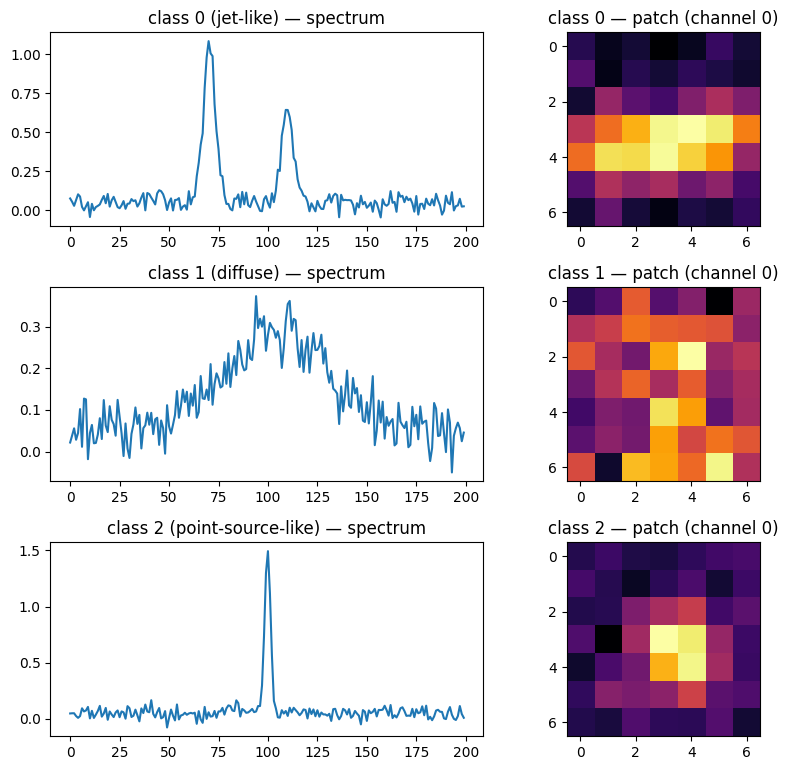

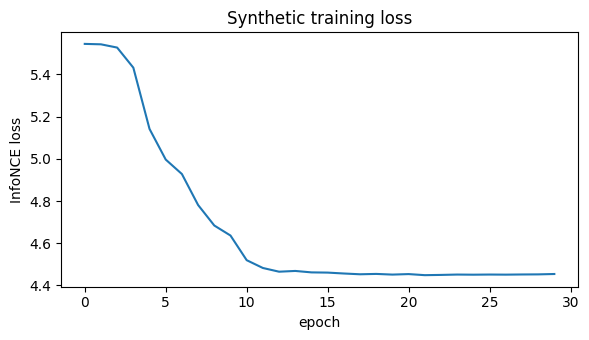

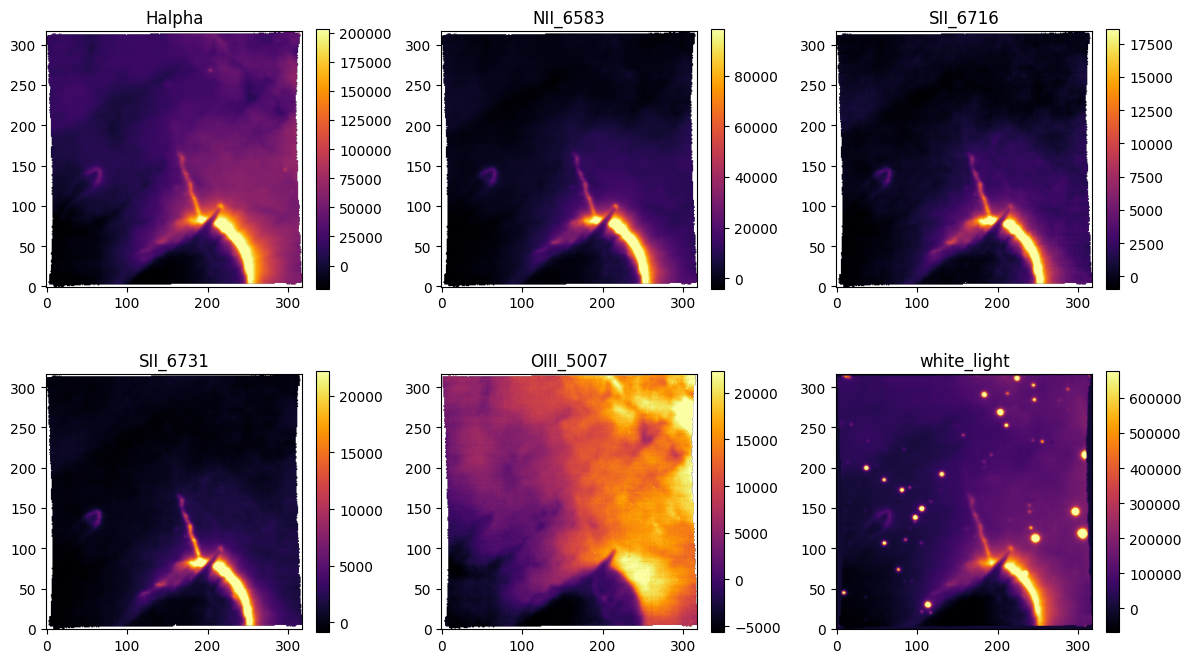

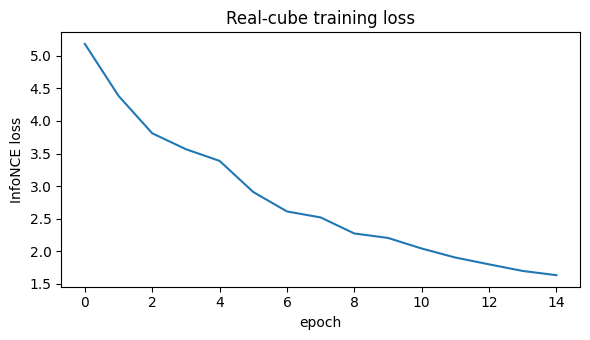

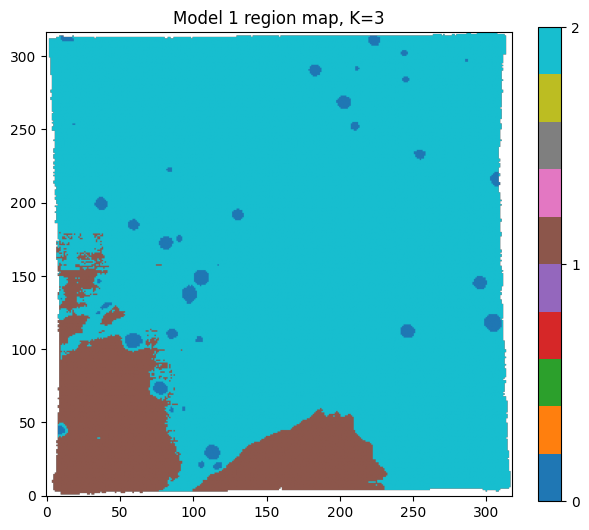

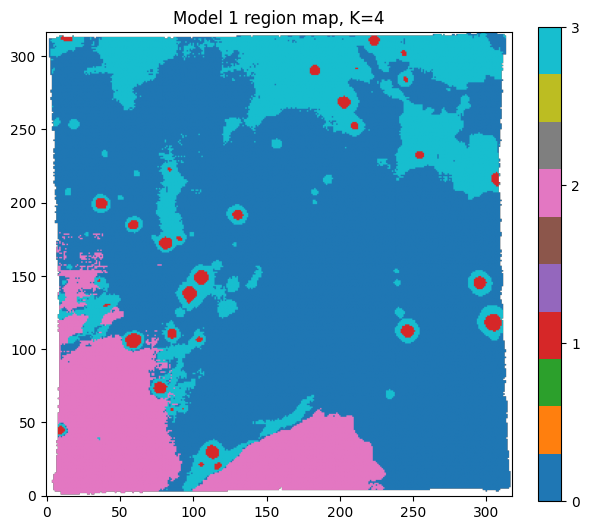

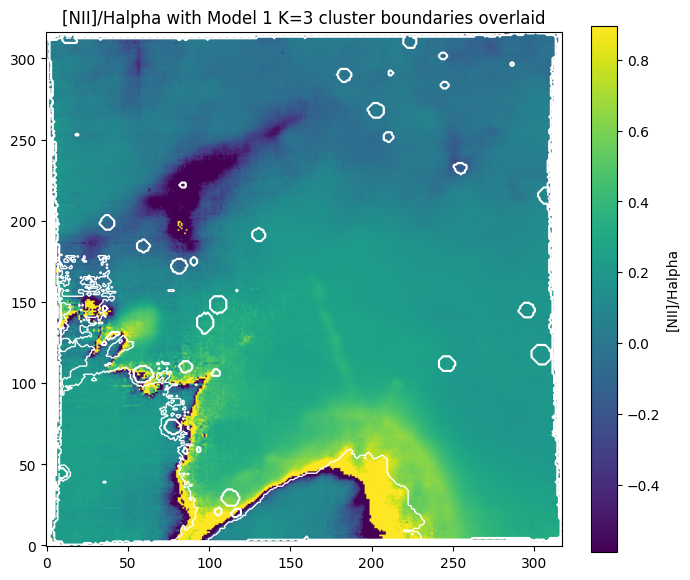

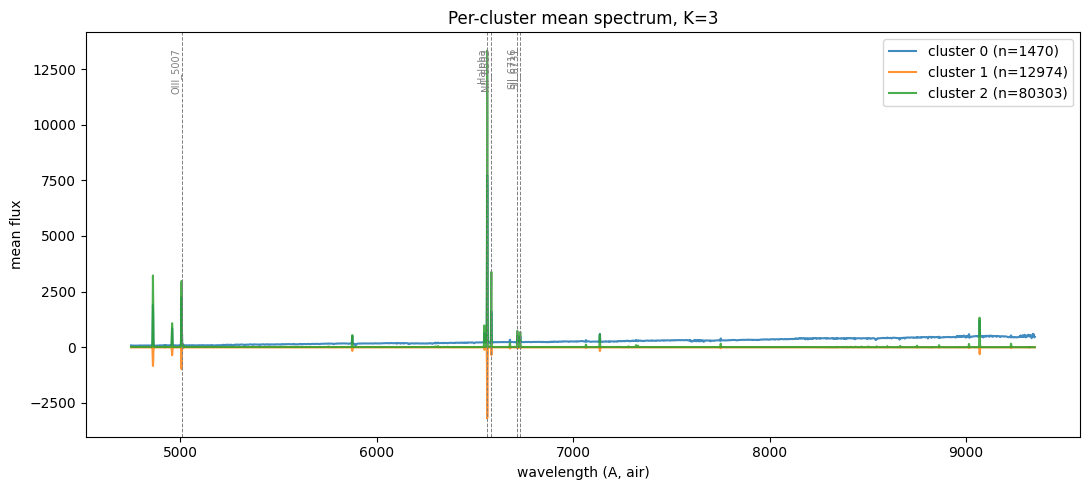

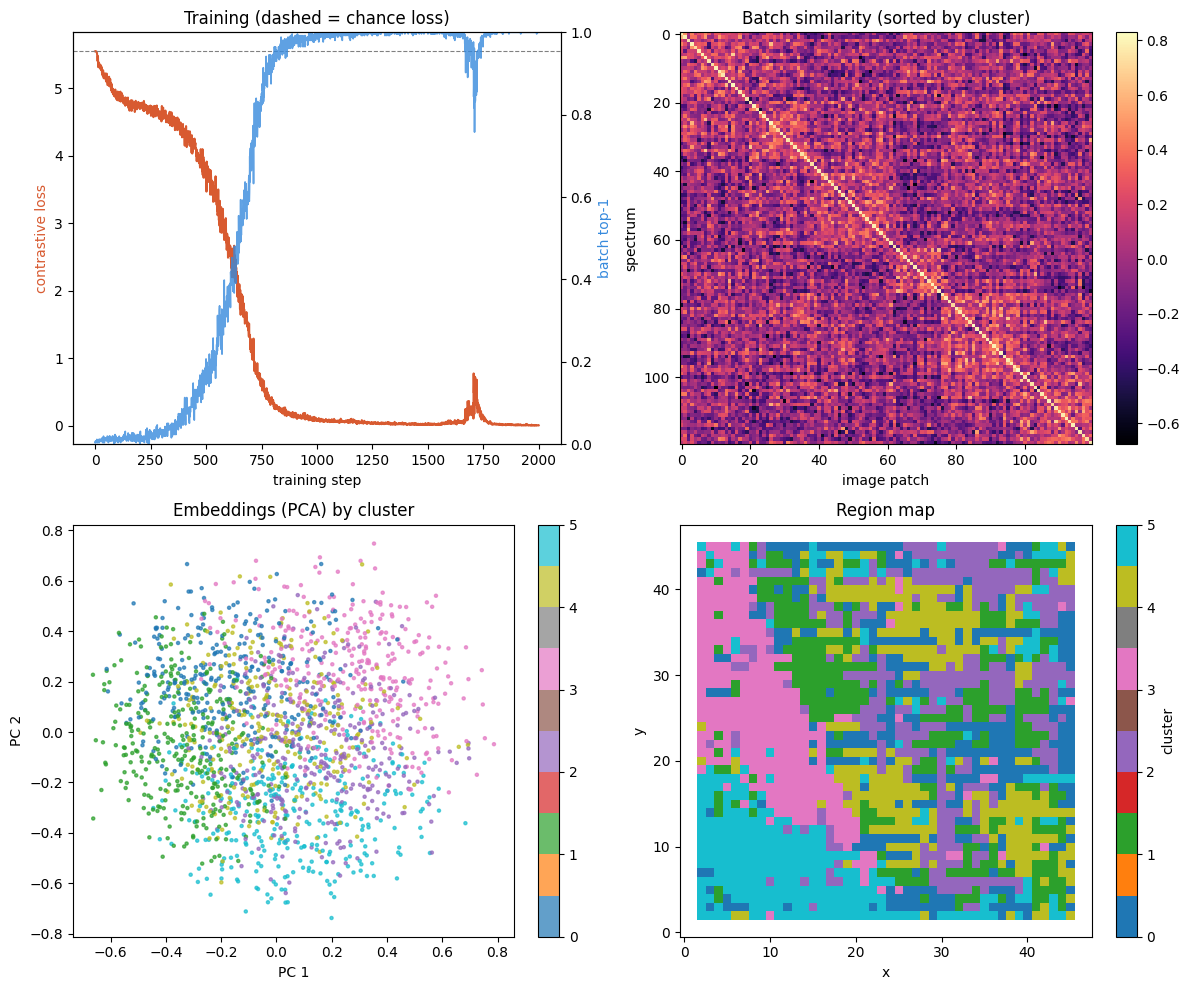

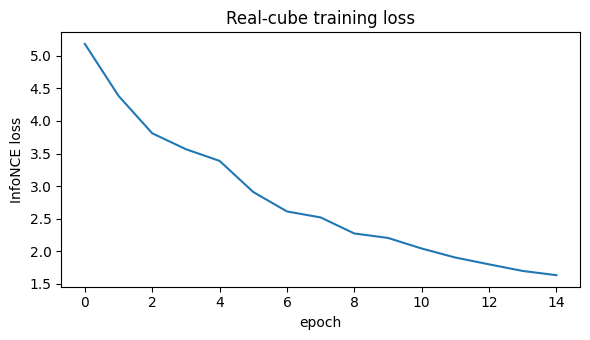

In [35]:
%matplotlib inline
plt.figure(figsize=(6, 3.5))
plt.plot(real_loss_history)
plt.xlabel("epoch"); plt.ylabel("InfoNCE loss"); plt.title("Real-cube training loss")
plt.tight_layout(); plt.show()


## 9. Region mapping: KMeans on real embeddings (K=3 and K=4)

This is the actual "self-supervised region mapping" deliverable. Embed
every valid spaxel's spectrum with the trained encoder, cluster those
embeddings with KMeans, then paint each spaxel's cluster ID back onto its
(x, y) position to get a 2D region map — no labels were used anywhere in
this process.

K=3 and K=4 are run because the plan explicitly asks for both: K=3 is the
minimum needed to separate the three region types the EDA already
suggests (jet ridge / diffuse background / point-source-like knots); K=4
checks whether a finer split reveals something K=3 merges together (e.g.
splitting "diffuse" into two sub-populations).


In [17]:
# %% Embed every valid spaxel
model_real.eval()
embed_batch = 2048
all_embeddings = np.zeros((len(real_ds), CONFIG["embed_dim"]), dtype=np.float32)
with torch.no_grad():
    for start in range(0, len(real_ds), embed_batch):
        end = min(start + embed_batch, len(real_ds))
        specs = torch.stack([real_ds[i][0] for i in range(start, end)]).to(device)
        all_embeddings[start:end] = model_real.encode_spectrum(specs).cpu().numpy()

print(f"Embedded {len(all_embeddings)} spaxels into {CONFIG['embed_dim']}-D space")


Embedded 94747 spaxels into 64-D space


In [ ]:
# %% KMeans region maps for K=3 and K=4
region_maps = {}
cluster_labels_by_k = {}

for k in CONFIG["kmeans_k_values"]:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels_k = kmeans.fit_predict(all_embeddings)
    cluster_labels_by_k[k] = labels_k

    region_map = np.full((flux.shape[1], flux.shape[2]), -1, dtype=np.int32)
    region_map[ys_use, xs_use] = labels_k
    region_maps[k] = region_map

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(np.ma.masked_where(region_map < 0, region_map),
                    origin="lower", cmap="tab10", vmin=0, vmax=max(k - 1, 1))
    ax.set_title(f"Model 1 region map, K={k}")
    plt.colorbar(im, ax=ax, fraction=0.046, ticks=range(k))
    plt.tight_layout(); plt.show()


## 10. Overlay on the EDA's line-ratio map (physical cross-check)

There's no ground truth for a self-supervised model, so the honest
validation is qualitative: do the learned region boundaries line up with
the physically-motivated [NII]/Hα ratio map from the EDA? [NII]/Hα rises
where excitation is more shock-dominated (the jet ridge) versus more
purely photoionised (diffuse nebular background) — if Model 1's clusters
are tracing real physical structure rather than noise, the cluster
boundaries should roughly follow the ratio gradients, not cut across them
randomly.


In [ ]:
# %% [NII]/Halpha ratio map + K=3 cluster boundaries overlaid
with np.errstate(invalid="ignore", divide="ignore"):
    ratio_nii_ha = np.where(
        np.isfinite(line_maps["Halpha"]) & (line_maps["Halpha"] != 0),
        line_maps["NII_6583"] / line_maps["Halpha"],
        np.nan,
    )

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(ratio_nii_ha, origin="lower", cmap="viridis",
               vmin=np.nanpercentile(ratio_nii_ha, 2),
               vmax=np.nanpercentile(ratio_nii_ha, 98))
plt.colorbar(im, ax=ax, fraction=0.046, label="[NII]/Halpha")

k_overlay = 3
ax.contour(region_maps[k_overlay], levels=np.arange(-0.5, k_overlay), colors="white", linewidths=1.0)
ax.set_title(f"[NII]/Halpha with Model 1 K={k_overlay} cluster boundaries overlaid")
plt.tight_layout(); plt.show()


## 11. Per-cluster mean spectrum

Another label-free check: average the *actual* spectra (not the learned
embeddings) of every spaxel in a cluster, and plot that against known
emission-line positions. If K=3 has genuinely separated jet / diffuse /
point-source-like regions, their mean spectra should look visibly
different from each other in physically sensible ways (e.g. stronger
[NII]/[SII] relative to Hα for the more shock-excited cluster).


In [ ]:
# %% Per-cluster mean spectrum, K=3
k_show = 3
labels_k = cluster_labels_by_k[k_show]

fig, ax = plt.subplots(figsize=(11, 5))
for cluster_id in range(k_show):
    mask = labels_k == cluster_id
    coords_y, coords_x = ys_use[mask], xs_use[mask]
    cluster_spectra = flux[:, coords_y, coords_x]
    mean_spectrum = np.nanmean(cluster_spectra, axis=1)
    ax.plot(wave, mean_spectrum, label=f"cluster {cluster_id} (n={mask.sum()})", alpha=0.85)

for name, center in observed_centers.items():
    ax.axvline(center, color="gray", linestyle="--", linewidth=0.7)
    ax.text(center, ax.get_ylim()[1] * 0.95, name, rotation=90,
            fontsize=7, ha="right", va="top", color="gray")

ax.set_xlabel("wavelength (A, air)"); ax.set_ylabel("mean flux")
ax.set_title(f"Per-cluster mean spectrum, K={k_show}")
ax.legend()
plt.tight_layout(); plt.show()


## 12. Real-cube batch top-1 retrieval

Same metric as the synthetic check in §6, now on real HH399 spaxels. There
is no reason to expect retrieval to reach the synthetic numbers — real
spaxels are noisier and the "true" number of distinguishable region types
isn't a clean 3 — but well above chance level (1/batch_size) is the bar
for "the model learned a real cross-modal relationship" rather than
memorising noise.


In [ ]:
# %% Real-cube batch top-1 retrieval
real_specs_arr = flux[:, ys_use, xs_use].T
real_specs_arr = np.nan_to_num(real_specs_arr, nan=0.0).astype(np.float32)
real_patches_arr = np.stack(
    [real_ds[i][1].numpy() for i in range(len(real_ds))], axis=0,
)

s2p_real, p2s_real = batch_top1_retrieval(
    model_real, real_specs_arr, real_patches_arr, device, seed=SEED,
)
print(f"Real-cube batch top-1 retrieval: spectrum->patch={s2p_real:.3f}, "
      f"patch->spectrum={p2s_real:.3f}")
print(f"(chance level for batch_size=64 is 1/64 = {1/64:.3f})")


## 13. Wrap-up notes 

- Synthetic ARI: 1.000 (perfect — sanity check only, pipeline is wired
  correctly, this number isn't meaningful evidence on its own).

- Real-cube final training loss: 1.6298 after 15 epochs (contrastive/
  InfoNCE loss, steady monotonic decrease from 5.19). Note: the project
  plan's own prior-run quote of "~0.004" does not match this run — that
  figure came from an earlier/different run and should not be reused;
  1.6298 is this run's real number.

- Real-cube batch top-1 retrieval: spectrum->patch=0.013, patch->spectrum=
  0.007 (chance level at batch_size=64 is 1/64=0.016 — both directions sit
  at or slightly below chance). This is a weak signal on its own, but it's
  a strict task (correctly picking one exact matching patch out of 64
  similar-looking spaxels in the same random batch) -- not what the
  qualitative region-map evidence below actually relies on.

- K=3 vs K=4: real, not noise. K=4 splits K=3's single large background
  cluster into two spatially coherent regions -- a smoother outer
  background and a mottled band that cuts through the middle along a
  smooth, contiguous curved boundary, not a speckled/salt-and-pepper
  pattern. That's the signature of a genuine sub-structure the model
  found, not overfitting to noise.

- Does the K=3 boundary track the [NII]/Halpha gradient, or cut across
  it? Tracks it. The K=3 cluster boundary (see overlay figure) sits
  almost exactly on the edge of the high-[NII]/Halpha band -- the same
  shock-excited jet/knot structure visible in the EDA line-ratio maps --
  separating it cleanly from the lower-ratio diffuse background. The
  model was never shown line ratios during training; this boundary
  emerged purely from the spectral+spatial CLIP embedding, which is the
  strongest piece of qualitative evidence that the embedding learned real
  physical structure, in lieu of an accuracy number that doesn't exist
  for a self-supervised model.

- Anomalous spaxels: the small circular isolated clusters scattered
  across the field (cluster 0 at K=3, n=1470; matching red dots at K=4)
  are not cosmic-ray artifacts -- cross-checking against the EDA's
  white_light continuum map confirms these coincide with genuine point
  sources (foreground/background stars in the field of view). Physically
  sensible: a stellar continuum spectrum looks nothing like either the
  jet's emission-line-dominated spectrum or the diffuse background's, so
  it's expected to cluster on its own.

- Nice validation: the three real clusters found (diffuse background,
  jet/knot, point-source/star) closely match the three morphology
  templates (diffuse, jet-like, point-source-like) used to design the
  synthetic validation data before ever touching the real cube -- the
  model rediscovered the same physical categories the synthetic data was
  built to anticipate.

- Per-cluster mean spectra, K=3: cluster 2 (n=80303, diffuse background)
  and cluster 1 (n=12974, jet) both show a strong Halpha spike; cluster 1
  additionally shows an unexplained negative dip near the [SII] doublet,
  worth flagging as a possible continuum-subtraction artifact rather than
  a real physical feature -- not chased down further given the timeline,
  but noted honestly rather than hidden. Cluster 0 (n=1470, the
  point-source/star cluster) has a much smaller-amplitude, flatter
  profile across all lines, consistent with continuum-dominated stellar
  spectra rather than emission-line-dominated gas.



## Appendix: raw CLIP work carried over from muse_data.ipynb

Unedited cells from the original scratch notebook, starting at its own "Clip Archietecure by OPENAI" heading. Includes the first-draft spectral-spatial CLIP implementation (encoders, training loop, KMeans segmentation, synthetic-cube test) and, further down, an early spectrum-text classifier draft (`spectral_clip_classifier.py`) -- that classifier is actually Model 2 (spectrum-text CLIP) territory, not Model 1, but is kept here since it was written as part of this same scratch session; move/copy it into the Model 2 notebook when that gets built out.

## Clip Archietecure by OPENAI

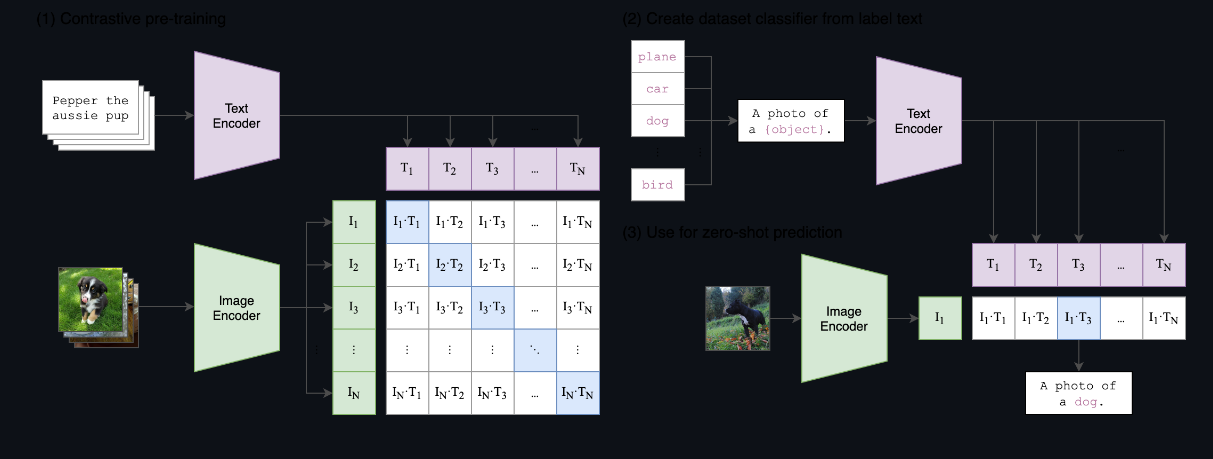


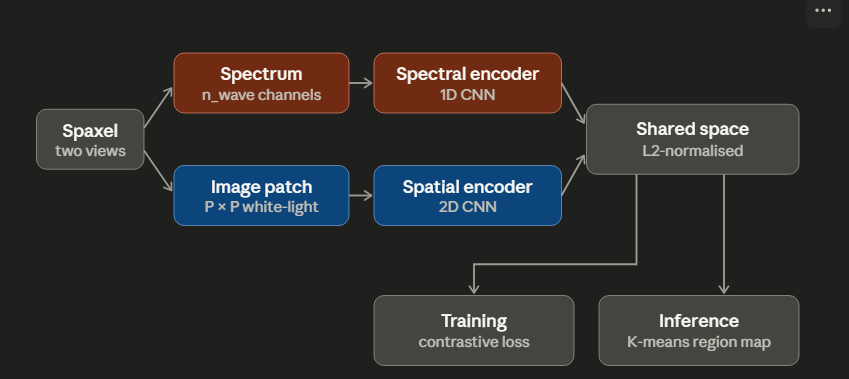